# Standardabweichung – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/standardabweichung)  
> Autor: Dr. Mathias Jesussek | Aktualisiert: 05.09.2025

Die **Standardabweichung** ist ein Streuungsmaß, das beschreibt, wie weit die einzelnen Datenpunkte im Durchschnitt vom **Mittelwert** entfernt sind.

| Standardabweichung | Bedeutung |
|---|---|
| **Gering (klein)** | Werte liegen eng um den Mittelwert → wenig Streuung |
| **Hoch (groß)** | Werte liegen weit vom Mittelwert → viel Streuung |
> Die Standardabweichung beantwortet die Frage:  
> **„Wie weit weichen die Werte im Durchschnitt vom Mittelwert ab?"**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Intuition: Was bedeutet Standardabweichung?

**Beispiel (numiqo):** 6 Personen werden nach ihrer Körpergröße befragt.  
Der Mittelwert beträgt **155 cm**. Jede Person weicht unterschiedlich weit vom Mittelwert ab:

| Person | Größe (cm) | Abweichung vom MW (155 cm) |
|---|---|---|
| 1 | 137 | −18 cm |
| 2 | 163 | +8 cm |
| 3 | 170 | +15 cm |
| 4 | 147 | −8 cm |
| 5 | 164 | +9 cm |
| 6 | 149 | −6 cm |

Die Standardabweichung ist die **mittlere Abweichung** aller Personen vom Mittelwert.  
In diesem Beispiel: **≈ 11,5 cm** – die Werte weichen also im Schnitt 11,5 cm vom Mittelwert ab.

Daten:      [137, 163, 170, 147, 164, 149] cm
Mittelwert: 155.0 cm

Abweichungen vom Mittelwert:
  Person 1: 137 cm  →  137 − 155 = -18 cm
  Person 2: 163 cm  →  163 − 155 = +8 cm
  Person 3: 170 cm  →  170 − 155 = +15 cm
  Person 4: 147 cm  →  147 − 155 = -8 cm
  Person 5: 164 cm  →  164 − 155 = +9 cm
  Person 6: 149 cm  →  149 − 155 = -6 cm


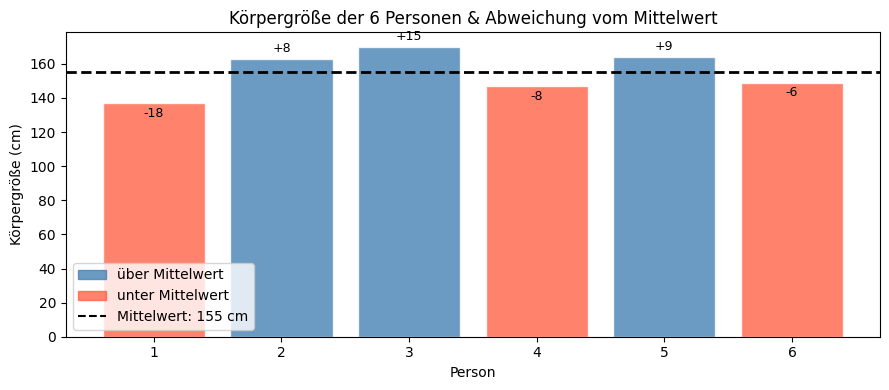

In [2]:
# numiqo-Beispiel: Körpergrössen
groessen = pd.Series([137, 163, 170, 147, 164, 149])
mw = groessen.mean()

print(f"Daten:      {list(groessen)} cm")
print(f"Mittelwert: {mw:.1f} cm")
print()

# Abweichungen
abw = groessen - mw
print("Abweichungen vom Mittelwert:")
for i, (g, a) in enumerate(zip(groessen, abw), 1):
    richtung = "+" if a >= 0 else ""
    print(f"  Person {i}: {g} cm  →  {g} − {mw:.0f} = {richtung}{a:.0f} cm")

# Visualisierung: Abweichungen
fig, ax = plt.subplots(figsize=(9, 4))
farben = ["tomato" if a < 0 else "steelblue" for a in abw]
ax.bar(range(1, 7), groessen, color=farben, edgecolor="white", alpha=0.8, label="Körpergröße")
ax.axhline(mw, color="black", linestyle="--", linewidth=2, label=f"Mittelwert: {mw:.0f} cm")
for i, (g, a) in enumerate(zip(groessen, abw)):
    ax.annotate(
        f"{'+' if a>=0 else ''}{a:.0f}",
        xy=(i + 1, g), xytext=(i + 1, g + (4 if a >= 0 else -8)),
        ha="center", fontsize=9, color="black"
    )
ax.set_title("Körpergröße der 6 Personen & Abweichung vom Mittelwert")
ax.set_xlabel("Person")
ax.set_ylabel("Körpergröße (cm)")
ax.set_xticks(range(1, 7))
ax.legend()
patch_pos = mpatches.Patch(color="steelblue", alpha=0.8, label="über Mittelwert")
patch_neg = mpatches.Patch(color="tomato",    alpha=0.8, label="unter Mittelwert")
ax.legend(handles=[patch_pos, patch_neg,
                   plt.Line2D([0],[0], color="black", linestyle="--",
                               label=f"Mittelwert: {mw:.0f} cm")])
plt.tight_layout()
plt.show()

## 2. Formel und Schritt-für-Schritt-Berechnung

### Formeln

**Populationsstandardabweichung** (alle Daten der Grundgesamtheit bekannt, Division durch $n$):
$$\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$

**Stichprobenstandardabweichung** (Schätzung aus Stichprobe, Division durch $n-1$):
$$s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$

### Warum quadrieren?

Würde man die Abweichungen einfach addieren, heben sich positive und negative Abweichungen gegenseitig auf (Summe ≈ 0). Durch das **Quadrieren** werden alle Abweichungen positiv gemacht.

### Berechnungsschritte

1. **Mittelwert** $\bar{x}$ berechnen
2. **Abweichungen** jedes Wertes vom Mittelwert berechnen: $x_i - \bar{x}$
3. Abweichungen **quadrieren**: $(x_i - \bar{x})^2$
4. **Summe** der quadrierten Abweichungen bilden
5. Durch $n$ (Population) oder $n-1$ (Stichprobe) **teilen** → Varianz
6. **Wurzel** ziehen → Standardabweichung

In [3]:
# Schritt-für-Schritt Berechnung – Körpergrössen-Beispiel
n  = len(groessen)
mw = groessen.mean()

abw      = groessen - mw          # Schritt 2
abw_quad = abw ** 2               # Schritt 3
summe    = abw_quad.sum()         # Schritt 4
varianz  = summe / n              # Schritt 5 (Population: /n)
std_pop  = np.sqrt(varianz)       # Schritt 6

print("Schritt-für-Schritt: Standardabweichung")
df = pd.DataFrame({
    "Person":      range(1, n+1),
    "xi (cm)":     groessen.values,
    "xi - xquer":  abw.round(2).values,
    "(xi-xquer)2": abw_quad.round(4).values,
})
print(df.to_string(index=False))
print()
print(f"Summe (xi-x_quer)^2 = {summe:.4f}")
print(f"Varianz sigma^2     = {summe:.4f} / {n} = {varianz:.4f} cm^2")
print(f"Std.-Abw. sigma     = sqrt({varianz:.4f}) = {std_pop:.2f} cm")
print()
print(f"Kontrolle (ddof=0): {groessen.std(ddof=0):.2f} cm  (stimmt mit Formel ueberein)")
print("Ergebnis numiqo:    ca. 11.5 cm")


Schritt-für-Schritt: Standardabweichung
 Person  xi (cm)  xi - xquer  (xi-xquer)2
      1      137       -18.0        324.0
      2      163         8.0         64.0
      3      170        15.0        225.0
      4      147        -8.0         64.0
      5      164         9.0         81.0
      6      149        -6.0         36.0

Summe (xi-x_quer)^2 = 794.0000
Varianz sigma^2     = 794.0000 / 6 = 132.3333 cm^2
Std.-Abw. sigma     = sqrt(132.3333) = 11.50 cm

Kontrolle (ddof=0): 11.50 cm  (stimmt mit Formel ueberein)
Ergebnis numiqo:    ca. 11.5 cm


## 3. Wann n, wann n−1? (Populations- vs. Stichproben-SD)

| Situation | Formel | Symbol | Python `ddof=` |
|---|---|---|---|
| **Alle Daten der Grundgesamtheit** bekannt | Division durch $n$ | $\sigma$ | `ddof=0` |
| Nur eine **Stichprobe** vorhanden (Normalfall!) | Division durch $n-1$ | $s$ | `ddof=1` (Standard) |

### Warum n−1? (Bessel-Korrektur)

Eine Stichprobe unterschätzt systematisch die wahre Streuung der Grundgesamtheit.  
Die Division durch $n-1$ korrigiert diesen **Bias** – man spricht von einem **unverzerrten Schätzer**.

> **Faustregel:** In der Praxis liegt fast immer eine **Stichprobe** vor  
> → fast immer **n−1** und Symbol **s** verwenden.

Population vs. Stichprobe
σ (ddof=0, Population):  11.5036 cm
s (ddof=1, Stichprobe):  12.6016 cm
Unterschied:             1.0980 cm



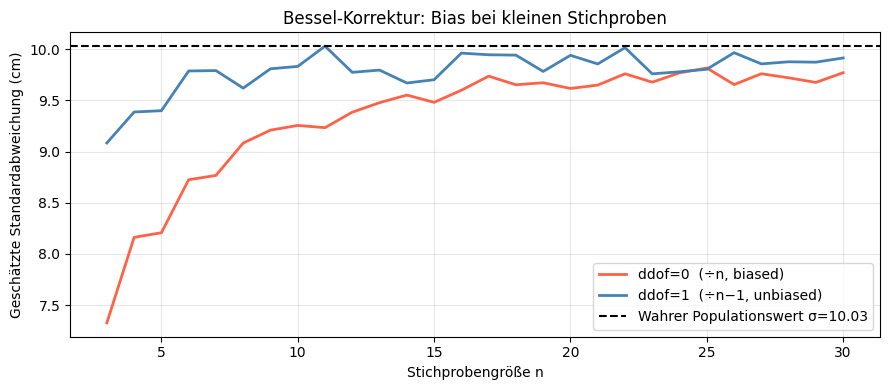

In [4]:
# Vergleich: ddof=0 (Population) vs. ddof=1 (Stichprobe)
std_pop   = groessen.std(ddof=0)   # σ – Grundgesamtheit
std_stich = groessen.std(ddof=1)   # s – Stichprobe

print("Population vs. Stichprobe")
print(f"σ (ddof=0, Population):  {std_pop:.4f} cm")
print(f"s (ddof=1, Stichprobe):  {std_stich:.4f} cm")
print(f"Unterschied:             {std_stich - std_pop:.4f} cm")
print()

# Visualisierung: Bias-Effekt bei kleinen Stichproben
np.random.seed(42)
population = np.random.normal(170, 10, 10000)
sigma_true = population.std(ddof=0)

n_werte = range(3, 31)
bias_n   = []
bias_n1  = []

for n_s in n_werte:
    sims = [np.random.choice(population, n_s, replace=False).std(ddof=0) for _ in range(500)]
    sims1= [np.random.choice(population, n_s, replace=False).std(ddof=1) for _ in range(500)]
    bias_n.append(np.mean(sims))
    bias_n1.append(np.mean(sims1))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_werte, bias_n,  color="tomato",    linewidth=2, label="ddof=0  (÷n, biased)")
ax.plot(n_werte, bias_n1, color="steelblue", linewidth=2, label="ddof=1  (÷n−1, unbiased)")
ax.axhline(sigma_true, color="black", linestyle="--", linewidth=1.5,
           label=f"Wahrer Populationswert σ={sigma_true:.2f}")
ax.set_title("Bessel-Korrektur: Bias bei kleinen Stichproben")
ax.set_xlabel("Stichprobengröße n")
ax.set_ylabel("Geschätzte Standardabweichung (cm)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Standardabweichung vs. Varianz

| | Standardabweichung | Varianz |
|---|---|---|
| **Formel** | $s = \sqrt{s^2}$ | $s^2 = \frac{\sum(x_i-\bar{x})^2}{n-1}$ |
| **Einheit** | Originaleinheit (z. B. cm) | Einheit² (z. B. cm²) |
| **Interpretation** | Direkt & intuitiv | Schwieriger |
| **Verhältnis** | $s = \sqrt{s^2}$ | $s^2 = s \cdot s$ |
| **Symbol** (Stichprobe) | $s$ | $s^2$ |
| **Symbol** (Population) | $\sigma$ | $\sigma^2$ |

> **Empfehlung:** Für die **Beschreibung** von Daten immer die  
> **Standardabweichung** verwenden, da sie in der Originaleinheit vorliegt  
> und somit direkt interpretierbar ist.

Standardabweichung vs. Varianz
Daten (Körpergröße): [137, 163, 170, 147, 164, 149] cm
Mittelwert:          155.00 cm

Varianz      s²  = 158.8000 cm²
  → Einheit: cm² (quadriert, schwer interpretierbar)

Standardabw. s   = √158.8000 = 12.6016 cm
  → Einheit: cm  (Originaleinheit, direkt interpretierbar)

Prüfung: √s² = √158.8000 = 12.6016 = s  ✓


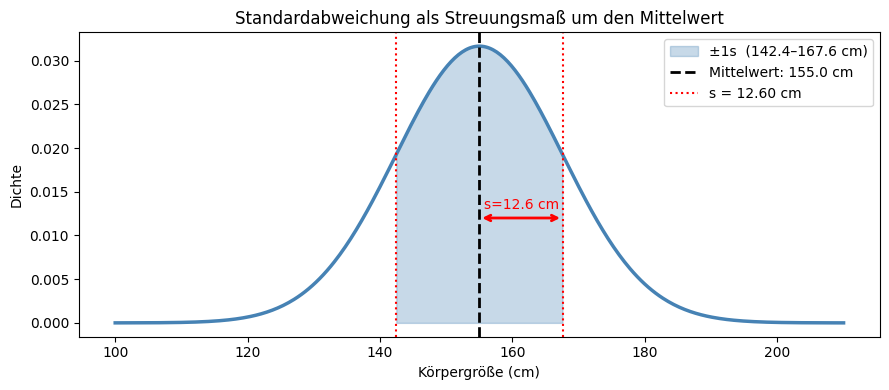

In [5]:
# Standardabweichung vs. Varianz – Vergleich
varianz_s = groessen.var(ddof=1)     # s²
std_s     = groessen.std(ddof=1)     # s

print("Standardabweichung vs. Varianz")
print(f"Daten (Körpergröße): {list(groessen)} cm")
print(f"Mittelwert:          {groessen.mean():.2f} cm")
print()
print(f"Varianz      s²  = {varianz_s:.4f} cm²")
print(f"  → Einheit: cm² (quadriert, schwer interpretierbar)")
print()
print(f"Standardabw. s   = √{varianz_s:.4f} = {std_s:.4f} cm")
print(f"  → Einheit: cm  (Originaleinheit, direkt interpretierbar)")
print()
print(f"Prüfung: √s² = √{varianz_s:.4f} = {np.sqrt(varianz_s):.4f} = s  ✓")

# Visualisierung: SD als Intervall um den Mittelwert
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(100, 210, 400)
from scipy.stats import norm
y = norm.pdf(x, groessen.mean(), std_s)
ax.plot(x, y, color="steelblue", linewidth=2.5)
mw_v = groessen.mean()
ax.fill_between(x, y,
    where=(x >= mw_v - std_s) & (x <= mw_v + std_s),
    color="steelblue", alpha=0.3,
    label=f"±1s  ({mw_v-std_s:.1f}–{mw_v+std_s:.1f} cm)")
ax.axvline(mw_v,         color="black", linestyle="--", linewidth=2,
           label=f"Mittelwert: {mw_v:.1f} cm")
ax.axvline(mw_v - std_s, color="red",   linestyle=":",  linewidth=1.5)
ax.axvline(mw_v + std_s, color="red",   linestyle=":",  linewidth=1.5,
           label=f"s = {std_s:.2f} cm")

# Pfeil-Annotation für s
ax.annotate("", xy=(mw_v + std_s, 0.012), xytext=(mw_v, 0.012),
            arrowprops=dict(arrowstyle="<->", color="red", lw=2))
ax.text(mw_v + std_s/2, 0.013, f"s={std_s:.1f} cm",
        ha="center", color="red", fontsize=10)

ax.set_title("Standardabweichung als Streuungsmaß um den Mittelwert")
ax.set_xlabel("Körpergröße (cm)")
ax.set_ylabel("Dichte")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Die 68–95–99,7-Regel (Empirische Regel)

Bei einer **Normalverteilung** gilt:

| Bereich | Anteil der Werte |
|---|---|
| $\bar{x} \pm 1s$ | ca. **68 %** |
| $\bar{x} \pm 2s$ | ca. **95 %** |
| $\bar{x} \pm 3s$ | ca. **99,7 %** |

Diese Regel ist extrem nützlich, um schnell einzuschätzen, wie viele Werte in einem bestimmten Bereich liegen – ohne aufwendige Berechnungen.

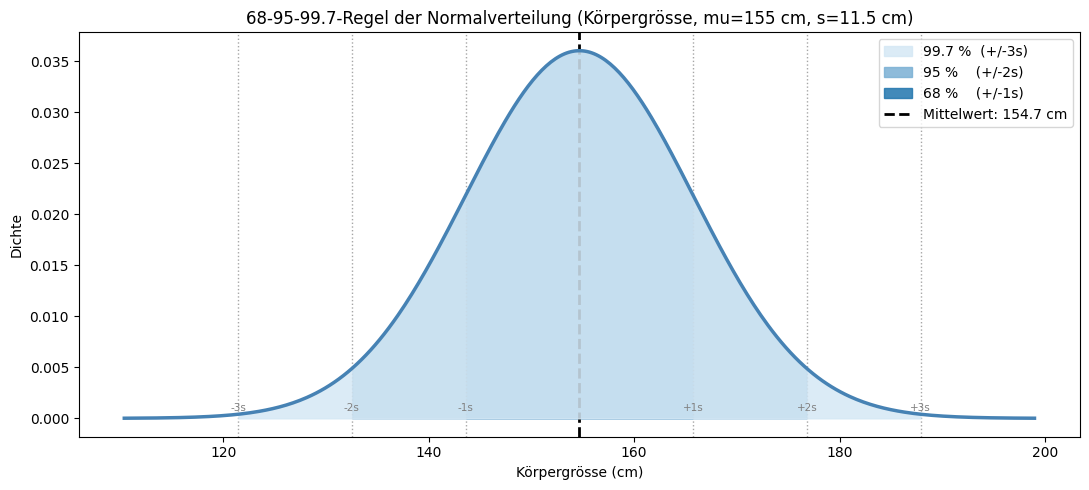

Empirische Prüfung (n=1000 simulierte Werte)
+/-1s:  67.6 %  (Theorie: 68.27 %)
+/-2s:  96.2 %  (Theorie: 95.45 %)
+/-3s:  99.7 %  (Theorie: 99.73 %)


In [6]:
# 68-95-99.7-Regel visualisieren
np.random.seed(7)
daten = np.random.normal(loc=155, scale=11.5, size=1000)
mu, s = daten.mean(), daten.std(ddof=1)

x = np.linspace(mu - 4*s, mu + 4*s, 400)
y = norm.pdf(x, mu, s)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, y, color="steelblue", linewidth=2.5, zorder=5)

schichten = [
    (3, "#d5e8f5", "99.7 %  (+/-3s)"),
    (2, "#7ab0d4", "95 %    (+/-2s)"),
    (1, "#2176ae", "68 %    (+/-1s)"),
]
for k, farbe, label in schichten:
    mask = (x >= mu - k*s) & (x <= mu + k*s)
    ax.fill_between(x[mask], y[mask], alpha=0.85, color=farbe, label=label, zorder=k)

ax.axvline(mu, color="black", linestyle="--", linewidth=2,
           label=f"Mittelwert: {mu:.1f} cm")

# Beschriftung der Sigma-Linien
for k in [1, 2, 3]:
    for sign in [-1, 1]:
        xpos = mu + sign * k * s
        ax.axvline(xpos, color="gray", linestyle=":", linewidth=1, alpha=0.7)
        sign_str = "+" if sign > 0 else "-"
        label_txt = sign_str + str(k) + "s"
        ax.text(xpos, max(y)*0.02, label_txt, ha="center", fontsize=7.5, color="gray")

ax.set_title("68-95-99.7-Regel der Normalverteilung (Körpergrösse, mu=155 cm, s=11.5 cm)")
ax.set_xlabel("Körpergrösse (cm)")
ax.set_ylabel("Dichte")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Empirische Prüfung
print("Empirische Prüfung (n=1000 simulierte Werte)")
for k in [1, 2, 3]:
    anteil = np.mean((daten >= mu - k*s) & (daten <= mu + k*s)) * 100
    theorie = {1: 68.27, 2: 95.45, 3: 99.73}[k]
    print(f"+/-{k}s:  {anteil:.1f} %  (Theorie: {theorie} %)")


## 6. Interpretation der Standardabweichung

### Was ist „groß" oder „klein"?

Die Standardabweichung ist **relativ** zu den Daten zu interpretieren.  
Hilfreich ist der **Variationskoeffizient (CV)** – die Standardabweichung relativ zum Mittelwert:

$$CV = \frac{s}{\bar{x}} \times 100\%$$

| CV | Interpretation |
|---|---|
| < 10 % | Sehr geringe Streuung |
| 10–20 % | Moderate Streuung |
| > 20 % | Hohe Streuung |

### Zwei Gruppen mit gleicher SD – unterschiedlichem Kontext

Eine SD von 5 kg bei Körpergewicht ist viel weniger auffällig  
als eine SD von 5 kg bei Kuchengewicht (Rezeptabweichung).

Variationskoeffizient (CV) im Vergleich
             Variable  Mittelwert  Std.-Abw.  CV (%) Streuung
    Körpergrösse (cm)         170         10     5.9   gering
    Tagesumsatz (EUR)        5000       2000    40.0     hoch
Pruefungsnoten (1-20)          12          3    25.0     hoch
         Gewicht (kg)          75          5     6.7   gering


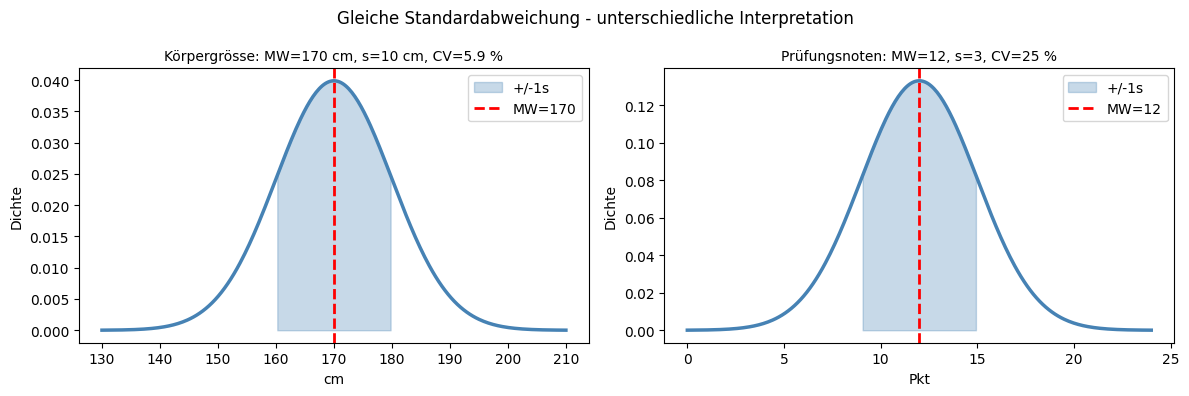

In [7]:
# Variationskoeffizient und Vergleich zweier Gruppen
beispiele = pd.DataFrame({
    "Variable":    ["Körpergrösse (cm)", "Tagesumsatz (EUR)", "Pruefungsnoten (1-20)", "Gewicht (kg)"],
    "Mittelwert":  [170,                   5000,                 12,                       75],
    "Std.-Abw.":   [10,                    2000,                  3,                        5],
})
beispiele["CV (%)"] = (beispiele["Std.-Abw."] / beispiele["Mittelwert"] * 100).round(1)
beispiele["Streuung"] = beispiele["CV (%)"].apply(
    lambda cv: "gering" if cv < 10 else ("moderat" if cv < 20 else "hoch"))
print("Variationskoeffizient (CV) im Vergleich")
print(beispiele.to_string(index=False))

# Visualisierung: zwei Gruppen mit gleicher SD, verschiedenem MW
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Gleiche Standardabweichung - unterschiedliche Interpretation", fontsize=12)

configs = [
    (170, 10, "cm",  "Körpergrösse: MW=170 cm, s=10 cm, CV=5.9 %"),
    (12,   3, "Pkt", "Prüfungsnoten: MW=12, s=3, CV=25 %"),
]
for ax, (mw_ex, s_ex, einheit, titel) in zip(axes, configs):
    x_ex = np.linspace(mw_ex - 4*s_ex, mw_ex + 4*s_ex, 300)
    y_ex = norm.pdf(x_ex, mw_ex, s_ex)
    ax.plot(x_ex, y_ex, color="steelblue", linewidth=2.5)
    ax.fill_between(x_ex, y_ex,
        where=(x_ex >= mw_ex - s_ex) & (x_ex <= mw_ex + s_ex),
        color="steelblue", alpha=0.3, label="+/-1s")
    ax.axvline(mw_ex, color="red", linestyle="--", linewidth=2,
               label=f"MW={mw_ex}")
    ax.set_title(titel, fontsize=10)
    ax.set_xlabel(einheit)
    ax.set_ylabel("Dichte")
    ax.legend()

plt.tight_layout()
plt.show()


## 7. Zusammenfassung

```
Standardabweichung – Übersicht
│
├── DEFINITION
│   └── Mittlere (quadratische) Abweichung aller Werte vom Mittelwert
│
├── FORMELN
│   ├── Population:  σ  = √[ Σ(xᵢ−μ)²  / n ]      (ddof=0)
│   └── Stichprobe:  s  = √[ Σ(xᵢ−x̄)² / (n−1) ]   (ddof=1)  ← Normalfall
│
├── BERECHNUNG (6 Schritte)
│   1. Mittelwert berechnen
│   2. Abweichungen: xᵢ − x̄
│   3. Quadrieren:   (xᵢ − x̄)²
│   4. Summieren:    Σ(xᵢ − x̄)²
│   5. Dividieren:   durch n oder n−1  → Varianz
│   └── 6. Wurzel ziehen              → Standardabweichung
│
├── VARIANZ vs. STANDARDABWEICHUNG
│   ├── Varianz:  s²  →  Einheit quadriert (cm²), schwer interpretierbar
│   └── Std.-Abw: s   →  Originaleinheit  (cm),  leicht interpretierbar
│
├── 68–95–99,7-REGEL (Normalverteilung)
│   ├── ±1s  →  ca. 68 % der Werte
│   ├── ±2s  →  ca. 95 % der Werte
│   └── ±3s  →  ca. 99,7 % der Werte
│
└── VARIATIONSKOEFFIZIENT  CV = s / x̄ × 100 %
    ├── < 10 %   → geringe Streuung
    ├── 10–20 %  → moderate Streuung
    └── > 20 %   → hohe Streuung
```

---
Quelle: [numiqo.de/tutorial/standardabweichung](https://numiqo.de/tutorial/standardabweichung)